In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('../data/online_retail_II.xlsx', 
                   sheet_name='online_retail_II')

df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['Revenue'] = df['Quantity'] * df['Price']
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f"Rows loaded: {len(df):,}")
print(f"Revenue: £{df['Revenue'].sum():,.0f}")

Rows loaded: 793,309
Revenue: £17,324,932


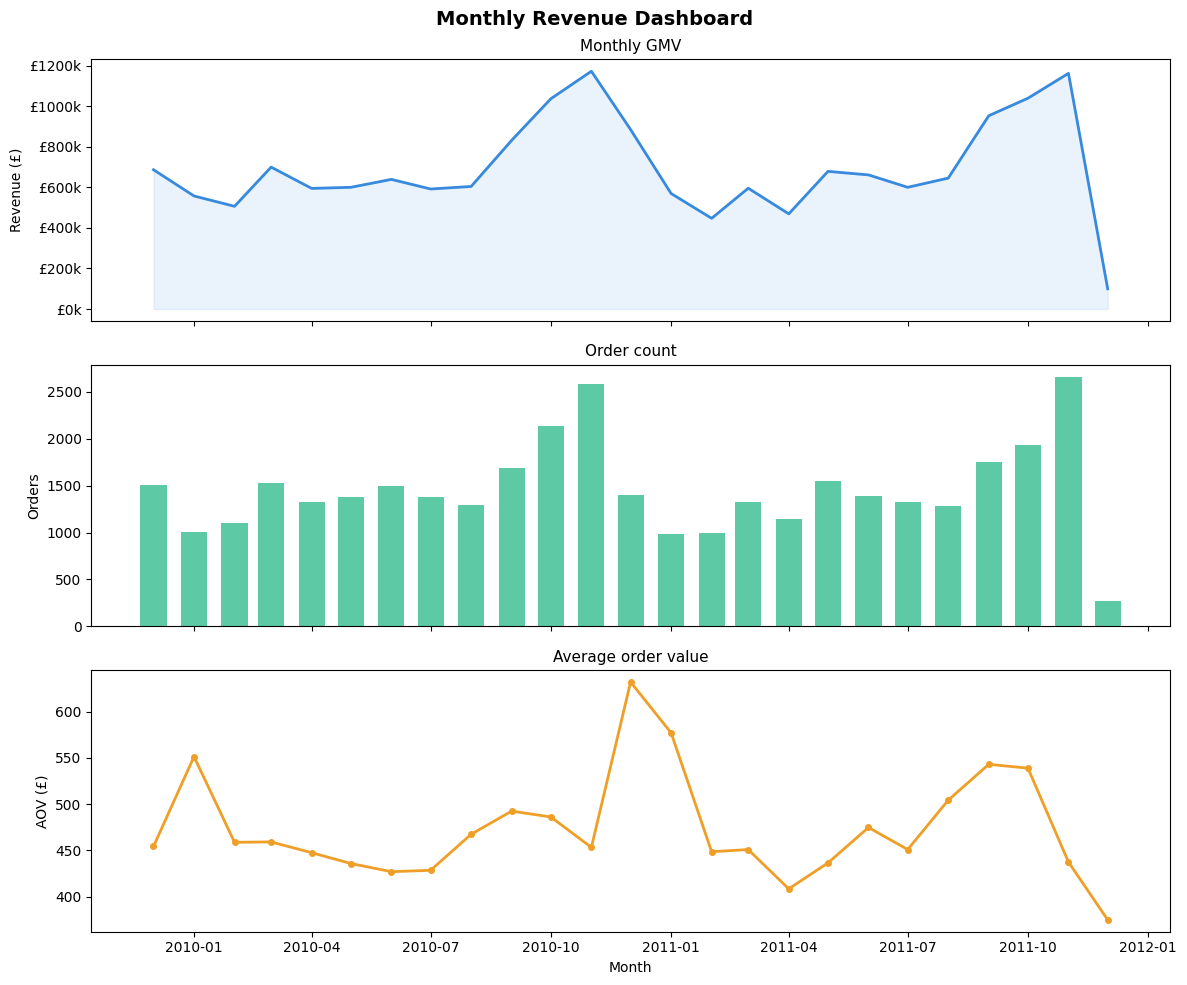


Monthly summary (last 6 months):
YearMonth     Revenue  Orders        AOV
  2011-07  600091.011    1331 450.857258
  2011-08  645343.900    1280 504.174922
  2011-09  952838.382    1755 542.927853
  2011-10 1039318.790    1929 538.786309
  2011-11 1161817.380    2657 437.266609
  2011-12   99713.700     266 374.863534


In [4]:
monthly = df.groupby('YearMonth').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()

monthly['AOV'] = monthly['Revenue'] / monthly['Orders']
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Monthly Revenue Dashboard', fontsize=14, fontweight='bold')

axes[0].plot(monthly['YearMonth_dt'], monthly['Revenue'],
             color='#378ADD', linewidth=2)
axes[0].fill_between(monthly['YearMonth_dt'], monthly['Revenue'],
                     alpha=0.1, color='#378ADD')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
axes[0].set_title('Monthly GMV', fontsize=11)

axes[1].bar(monthly['YearMonth_dt'], monthly['Orders'],
            color='#5DCAA5', width=20)
axes[1].set_ylabel('Orders')
axes[1].set_title('Order count', fontsize=11)

axes[2].plot(monthly['YearMonth_dt'], monthly['AOV'],
             color='#EF9F27', linewidth=2, marker='o', markersize=4)
axes[2].set_ylabel('AOV (£)')
axes[2].set_xlabel('Month')
axes[2].set_title('Average order value', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/01_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMonthly summary (last 6 months):")
print(monthly[['YearMonth','Revenue','Orders','AOV']].tail(6).to_string(index=False))

In [5]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5,
                          labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5,
                          labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5,
                          labels=[1,2,3,4,5]).astype(int)

def assign_segment(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4:    return 'Champions'
    elif r >= 3 and f >= 3:  return 'Loyal'
    elif r >= 4 and f <= 2:  return 'New customers'
    elif r <= 2 and f >= 3:  return 'At risk'
    elif r <= 2 and f <= 2:  return 'Lost'
    else:                    return 'Potential loyalists'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("── Segment counts ──")
print(rfm['Segment'].value_counts().to_string())
print("\n── Revenue by segment ──")
print(rfm.groupby('Segment')['Monetary'].sum()
        .sort_values(ascending=False)
        .apply(lambda x: f'£{x:,.0f}').to_string())

── Segment counts ──
Segment
Lost                   1504
Champions              1468
Loyal                  1212
At risk                 836
New customers           475
Potential loyalists     365

── Revenue by segment ──
Segment
Champions              £12,128,559
Loyal                   £2,475,181
At risk                 £1,636,314
Lost                      £647,292
New customers             £243,006
Potential loyalists       £194,581


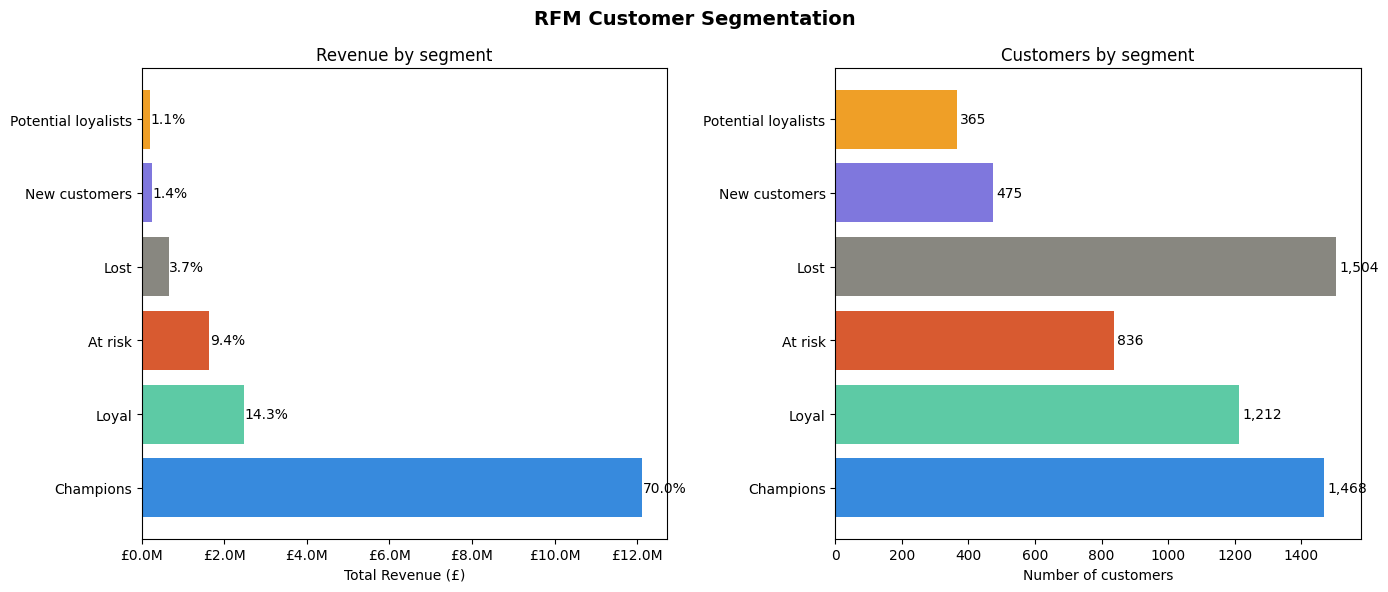

In [6]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Revenue=('Monetary', 'sum')
).reset_index().sort_values('Revenue', ascending=False)

segment_summary['Revenue_Share'] = (
    segment_summary['Revenue'] / segment_summary['Revenue'].sum() * 100
).round(1)

colors = {
    'Champions': '#378ADD',
    'Loyal': '#5DCAA5',
    'Potential loyalists': '#EF9F27',
    'New customers': '#7F77DD',
    'At risk': '#D85A30',
    'Lost': '#888780'
}
bar_colors = segment_summary['Segment'].map(colors).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

axes[0].barh(segment_summary['Segment'], segment_summary['Revenue'],
             color=bar_colors)
axes[0].set_xlabel('Total Revenue (£)')
axes[0].set_title('Revenue by segment')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for i, (rev, share) in enumerate(zip(segment_summary['Revenue'],
                                      segment_summary['Revenue_Share'])):
    axes[0].text(rev + 20000, i, f'{share}%', va='center', fontsize=10)

axes[1].barh(segment_summary['Segment'], segment_summary['Customers'],
             color=bar_colors)
axes[1].set_xlabel('Number of customers')
axes[1].set_title('Customers by segment')
for i, v in enumerate(segment_summary['Customers']):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/02_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

── CLV by segment ──
                     Customers  Avg_CLV  Median_CLV  Avg_AOV  Avg_Orders
Segment                                                                 
Champions                 1468  8261.96     3470.86   425.42       15.51
Loyal                     1212  2042.23     1222.85   370.93        5.40
At risk                    836  1957.31     1034.66   368.46        4.90
Potential loyalists        365   533.10      364.50   389.41        1.38
New customers              475   511.59      383.03   354.27        1.43
Lost                      1504   430.38      282.77   343.69        1.24


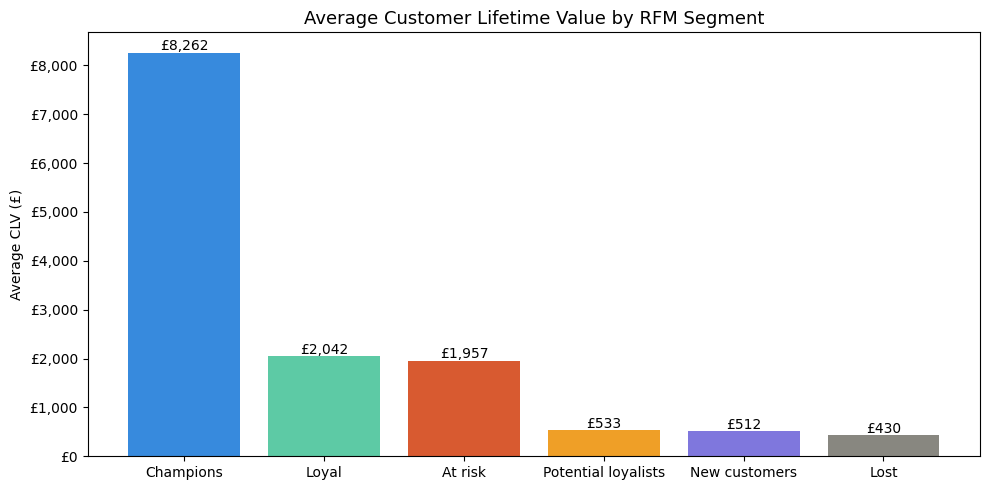

In [7]:
customer_stats = df.groupby('Customer ID').agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('Invoice', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
).reset_index()

customer_stats['lifespan_days'] = (
    customer_stats['last_purchase'] -
    customer_stats['first_purchase']
).dt.days.clip(lower=1)

customer_stats['AOV'] = (
    customer_stats['total_revenue'] / customer_stats['total_orders'])

clv_df = customer_stats.merge(
    rfm[['Customer ID', 'Segment']], on='Customer ID')

clv_summary = clv_df.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_CLV=('total_revenue', 'mean'),
    Median_CLV=('total_revenue', 'median'),
    Avg_AOV=('AOV', 'mean'),
    Avg_Orders=('total_orders', 'mean')
).round(2).sort_values('Avg_CLV', ascending=False)

print("── CLV by segment ──")
print(clv_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
segments = clv_summary.index.tolist()
avg_clvs = clv_summary['Avg_CLV'].tolist()
seg_colors = [colors.get(s, '#888780') for s in segments]

bars = ax.bar(segments, avg_clvs, color=seg_colors)
ax.set_ylabel('Average CLV (£)')
ax.set_title('Average Customer Lifetime Value by RFM Segment', fontsize=13)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, avg_clvs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'£{val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/03_clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

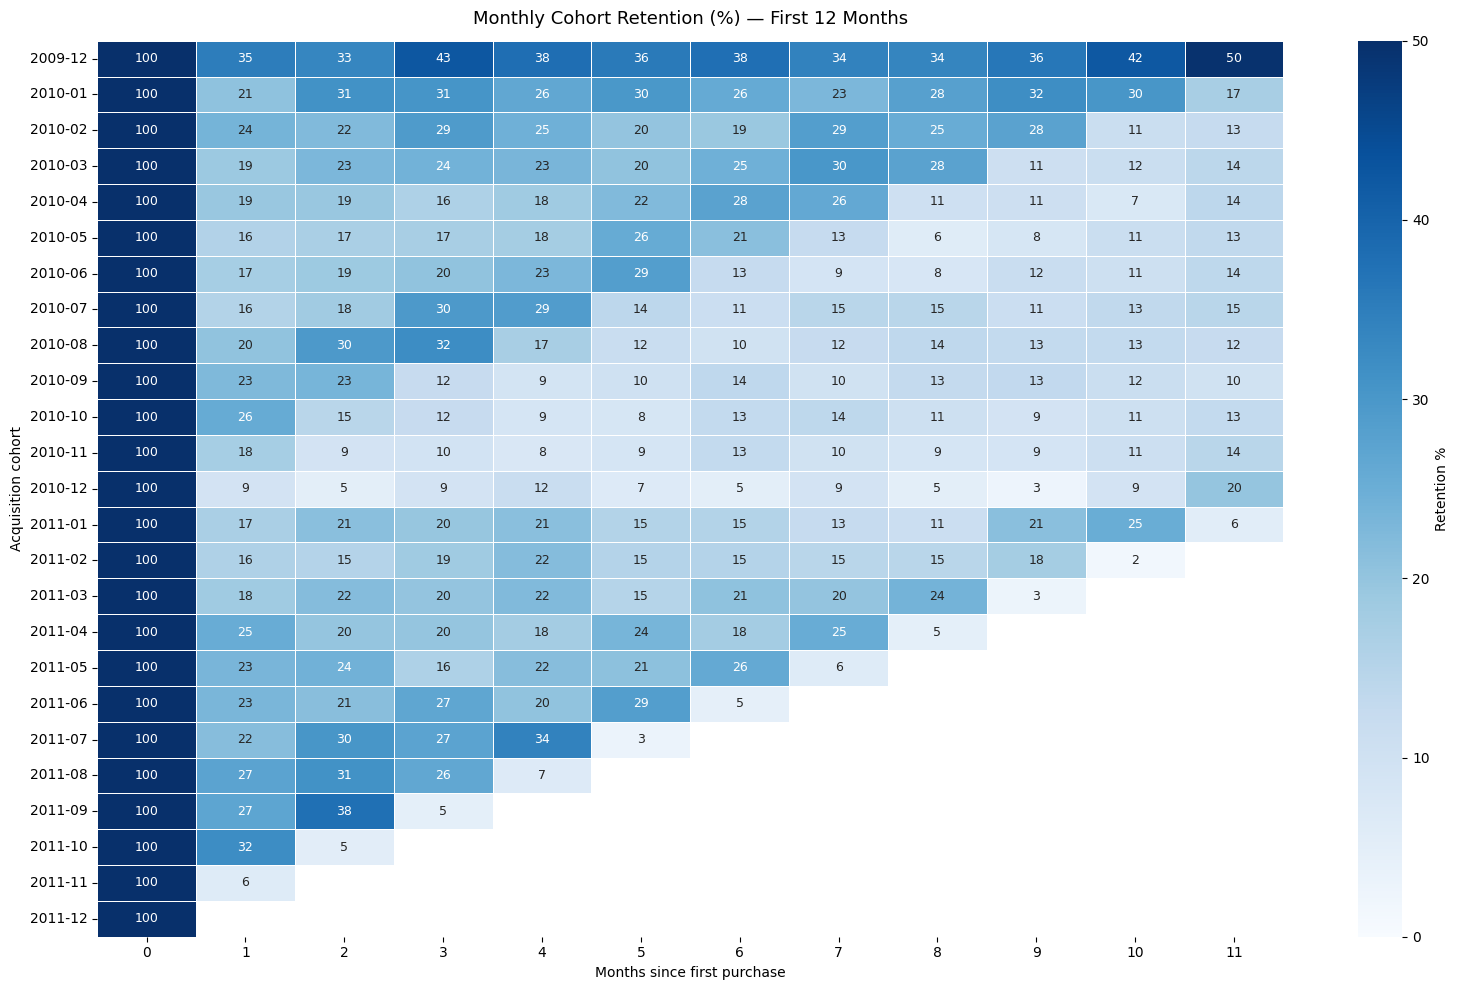

── Month 1 retention by cohort ──
CohortMonth
2009-12    35.3
2010-01    20.6
2010-02    23.8
2010-03    19.0
2010-04    19.4
2010-05    15.7
2010-06    17.4
2010-07    15.6
2010-08    20.4
2010-09    22.6
2010-10    25.7
2010-11    17.5
2010-12     9.2
2011-01    16.9
2011-02    16.1
2011-03    18.4
2011-04    25.5
2011-05    23.4
2011-06    23.1
2011-07    21.6
2011-08    27.4
2011-09    27.0
2011-10    32.1
2011-11     6.3
Freq: M

Average Month-1 retention: 20.8%


In [8]:
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'] \
                      .transform('min').dt.to_period('M')
df['CohortIndex'] = (
    df['YearMonth'] - df['CohortMonth']).apply(lambda x: x.n)

cohort_data = df.groupby(
    ['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth', columns='CohortIndex', values='Customer ID')

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(16, 10))
sns.heatmap(
    retention.iloc[:, :12],
    annot=True, fmt='.0f',
    cmap='Blues', linewidths=0.5,
    cbar_kws={'label': 'Retention %'},
    vmin=0, vmax=50,
    annot_kws={'size': 9}
)
plt.title('Monthly Cohort Retention (%) — First 12 Months',
          fontsize=13, pad=12)
plt.xlabel('Months since first purchase')
plt.ylabel('Acquisition cohort')
plt.tight_layout()
plt.savefig('../outputs/04_cohort_retention.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("── Month 1 retention by cohort ──")
month1 = retention.iloc[:, 1].dropna().round(1)
print(month1.to_string())
print(f"\nAverage Month-1 retention: {month1.mean():.1f}%")